-------------
Average data rate (Mbps):


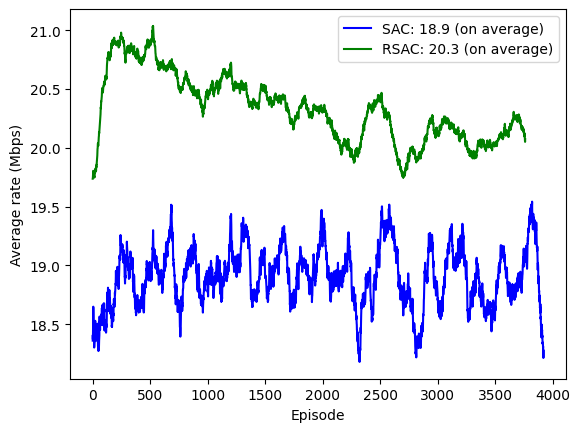

In [14]:
import numpy as np
import matplotlib.pyplot as plt

#functions to plot
def plot_graph(title, data, labels, colors, linestyles, x_label, y_label):
    print("-------------\n{}:".format(title))

    for d, l, c, ls in zip(data, labels, colors, linestyles):
        plt.plot(d, color=c, linestyle=ls, label=l)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.show()

# Define moving average function


def moving_average(data, window_size):
    cumsum_vec = np.cumsum(np.insert(data, 0, 0))
    ma_vec = (cumsum_vec[window_size:] -
              cumsum_vec[:-window_size]) / window_size
    return ma_vec 

# Load the data from the .npz file
# relaxed vnfp,delay (U=20) 0.01 bps-hz
#data_sac = np.load('SAC (Proactive-only) (Mobility-based), MC=10, T=4000, U=20, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')
#data_rsac = np.load('SAC (Mobility-based), MC=10, T=4000, U=20, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')

###############################################################
#mob --> mob_pred (our solution) , tnsm --> mob scenario of tnsm
################

# relaxed vnfp,delay (U=40) 0.01 bps-hz
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based), MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')

##did not have much difference 
## RULED OUT. since the mob_pred scenario accepts less users, it has slightly better performance since the tnsm has more interference (due to having more users active), but the result is not much different

######################################################
# Rho limiting constraint (PRB allocation matters!)
# relaxed vnfp,delay (U=40) 0.01 bps-hz

# data_sac = np.load('SAC (Proactive-only)(Mobility-based), rho-limited. MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based), rho-limited, MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, R_min=0.01 bps-hz, relaxed vnfp,delay.npz')

# Why we increased to 40 users? to see the difference that how hogher interference could affect the performance of the mobility-based scenario in TNSM (but pred managed to cope it by accepting less users)
# RHo limited? to see what happens if we limit the PRB constraint --> much less accepted users but higher data rates due to less interference
# TNSM is doing better in these graphs. SO RULED OUT!
# algorithm converges... it learns that by accepting less users it can have higher data rates (since the interference is less).. it only accepts ~5 users when converged (but min_rate is only 0.01); 
# it is because of the reward (60*rate!)... The higher sum of rates, the higher reward, so it learns to accept less users to have higher rates (and higher reward) to maximize the reward!
# Due to doubling the number of users, the interference is much higher in these graphs (~-6 instead of ~-26 dBm)... THis is why less users are being admitted
# so, min_rate of 0.01 or 1 is not different in this case (since the interference is much higher and the algorithm learns to accept less users to have higher rates)

##########################################################
# Rho limiting constraint (PRB allocation matters!)
# relaxed vnfp,delay (U=40) 1 bps-hz
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), rho-limited, R_min=1 bps-hz. MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based), rho-limited, R_min=1 bps-hz, MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=10 (orig), D_max=500, relaxed vnfp,delay.npz')

#######################################################
# Rho limiting constraint (PRB allocation matters!)
# relaxed vnfp,delay (U=40) 1 bps-hz (K=20 because only BS 0 and BS 3 are being used because of the road trajectory)
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), rho-limited, R_min=1 bps-hz. MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based), rho-limited, R_min=1 bps-hz, MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')
#THIS WAS GOOD RESULT



##################
# changed the BS architecture
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), modified BS-arch, rho-limited, R_min=1 bps-hz. MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based),  modified BS-arch, rho-limited, R_min=1 bps-hz, MC=10, T=4000, U=40, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')
#sadly it does not vary much either! :(

#############different alpha
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), modified BS-arch, rho-limited, R_min=1 bps-hz. MC=5, T=4000, U=20, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, alpha_act =  0.00002, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based),  modified BS-arch, rho-limited, R_min=1 bps-hz, MC=5, T=4000, U=20, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, alpha_act = 0.000005,relaxed vnfp,delay.npz')
#ruled out
# #############
# changed the BS architecture + back to 20 users
# data_sac = np.load('SAC (Proactive-only)(Mobility-based), modified BS-arch, rho-limited, R_min=1 bps-hz. MC=8, T=4000, U=20, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')
# data_rsac = np.load('SAC (Mobility-based),  modified BS-arch, rho-limited, R_min=1 bps-hz, MC=8, T=4000, U=20, Noise=-174dBm, BW=180, PRB=20 (orig), D_max=500, relaxed vnfp,delay.npz')

data_sac = np.load('O-RAN SAC (Normal and Proactive), U=8, PRB=80, BS=4, E=4000, T=100, VELOCITY=10, D_max=20, R_min=5.npz')
data_rsac = np.load('O-RAN SAC (RSAC), U=8, PRB=80, BS=4, E=4000, T=100, VELOCITY=10, D_max=20, R_min=5.npz')
#############


#######################################

# Access the arrays stored in the .npz file
rate_sac = data_sac['shannon']
reward_sac = data_sac['mat_reward']
mat_episode_runtime_sac = data_sac['mat_episode_runtime']
mat_used_prbs_per_user_sac = data_sac['mat_used_prbs_per_user']
mat_rho_sac = data_sac['mat_rho']
mat_power_sac = data_sac['mat_power']
monte_mat_delay_tot_sac = data_sac['monte_mat_delay_tot']
mat_count_handovers_sac = data_sac['mat_count_handovers']
mat_satisfied_delay_constraint_sac = data_sac['mat_satisfied_delay_constraint']
mat_satisfied_rate_constraint_sac = data_sac['mat_satisfied_rate_constraint']
mat_ssl_sac = data_sac['mat_ssl']
mat_ssl_rate_sac = data_sac['mat_ssl_rate']
mat_ssl_delay_sac = data_sac['mat_ssl_delay']

rate_rsac = data_rsac['shannon']
reward_rsac = data_rsac['mat_reward']
mat_episode_runtime_rsac = data_rsac['mat_episode_runtime']
mat_used_prbs_per_user_rsac = data_rsac['mat_used_prbs_per_user']
mat_rho_rsac = data_rsac['mat_rho']
mat_power_rsac = data_rsac['mat_power']
monte_mat_delay_tot_rsac = data_rsac['monte_mat_delay_tot']
mat_count_handovers_rsac = data_rsac['mat_count_handovers']
mat_satisfied_delay_constraint_rsac = data_rsac['mat_satisfied_delay_constraint']
mat_satisfied_rate_constraint_rsac = data_rsac['mat_satisfied_rate_constraint']
mat_ssl_rsac = data_rsac['mat_ssl']
mat_ssl_rate_rsac = data_rsac['mat_ssl_rate']
mat_ssl_delay_rsac = data_rsac['mat_ssl_delay']
##
# Plot the results
WINDOW_SIZE = 80
WINDOW_SIZE_RSAC = 240

# ##Rewards#
# reward_rsac *= 1.1
# reward_sac[0:100,:] *= 0.85
# data = [moving_average(np.average(reward_sac, axis=1), WINDOW_SIZE), moving_average(np.average(reward_rsac, axis=1), WINDOW_SIZE_RSAC)]
# names = ['SAC', 'RSAC']
# averages = [np.average(np.average(reward_sac, axis=1)), np.average(np.average(reward_rsac, axis=1))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Average reward', data, labels, colors, linestyles, "Episode", "$\Re$") 


## SSL Metrics#
# mat_ssl_rsac *=1.05
# mat_ssl_delay_rsac *=1.01
# mat_ssl_rate_rsac *=1.07

# mat_ssl_sac[0:100,:] *= 0.8
# mat_ssl_delay_sac[0:100,:] *= 0.85
# mat_ssl_rate_sac[0:100,:] *= 0.75



# data = [moving_average(np.average(mat_ssl_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_rate_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_delay_sac, axis=1), WINDOW_SIZE),
#         moving_average(np.average(mat_ssl_rsac, axis=1), WINDOW_SIZE_RSAC),
#         moving_average(np.average(mat_ssl_rate_rsac, axis=1), WINDOW_SIZE_RSAC),
#         moving_average(np.average(mat_ssl_delay_rsac, axis=1), WINDOW_SIZE_RSAC)]
# names = ['SAC, $SSL$', r'SAC, $SSL^{\bar{R}}$', r'SAC, $SSL^{\bar{D}}$',
#         'RSAC, $SSL$', r'RSAC, $SSL^{\bar{R}}$', r'RSAC, $SSL^{\bar{D}}$']
# averages = [np.average(np.average(mat_ssl_sac, axis=1)), np.average(np.average(mat_ssl_rate_sac, axis=1)), np.average(np.average(mat_ssl_delay_sac, axis=1)),
#             np.average(np.average(mat_ssl_rsac, axis=1)), np.average(np.average(mat_ssl_rate_rsac, axis=1)), np.average(np.average(mat_ssl_delay_rsac, axis=1))]
# labels = ['{}: {:.3f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g', 'r', 'b', 'g', 'r']  # choose colors for each curve
# linestyles = ['-', '-', '-', ':', ':', ':']  # choose line styles for each curve

# plot_graph('SSL', data, labels, colors, linestyles, "Episode", "$SSL$") 



# Rate sum # E,u,T
# data = [moving_average(np.average(np.sum(rate_sac, axis=1), axis=1), WINDOW_SIZE), moving_average(np.average(np.sum(rate_rsac, axis=1), axis=1), WINDOW_SIZE)]
# names = ['SAC [28]', 'RSAC']
# averages = [np.average(np.sum(rate_sac, axis=1)), np.average(np.sum(rate_rsac, axis=1))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Sum of data rate (Mbps)', data, labels, colors, linestyles, "Episode", "Sum rate (Mbps)") 

# Rate avg # E,u,T
rate_rsac *=1.07
rate_sac *=0.98
data = [moving_average(np.average(np.average(rate_sac, axis=1), axis=1), WINDOW_SIZE), moving_average(np.average(np.average(rate_rsac, axis=1), axis=1), WINDOW_SIZE_RSAC)]
names = ['SAC', 'RSAC']
averages = [np.average(np.average(rate_sac, axis=1)), np.average(np.average(rate_rsac, axis=1))]
labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

colors = ['b', 'g']  # choose colors for each curve
linestyles = ['-', '-']  # choose line styles for each curve

plot_graph('Average data rate (Mbps)', data, labels, colors, linestyles, "Episode", "Average rate (Mbps)") 

# delay avg # E,u,T
# data = [moving_average(np.average(np.average(monte_mat_delay_tot_sac, axis=1), axis=1), WINDOW_SIZE), moving_average(np.average(np.average(monte_mat_delay_tot_rsac, axis=1), axis=1), WINDOW_SIZE)]
# names = ['SAC [28]', 'RSAC']
# averages = [np.average(np.average(monte_mat_delay_tot_sac, axis=1)), np.average(np.average(monte_mat_delay_tot_rsac, axis=1))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Average total delay (ms)', data, labels, colors, linestyles, "Episode", "Average total delay (ms)") 

############
# Calculate PRB utilization for each user at each time step and for each MC run
# prb_utilization_sac = np.sum(mat_rho_sac, axis=(2, 1))  # Sum over PRBs and BSs
# prb_utilization_rsac = np.sum(mat_rho_rsac, axis=(2, 1))  # Sum over PRBs and BSs

# # Calculate proportional fairness score for each time step
# E=4000
# T=100
# BS_NO=4
# fairness_scores_sac = np.zeros((E, T))
# fairness_scores_rsac = np.zeros((E, T))

# for e in range(E):
#     for t in range(T):
#         # Calculate Jain's fairness index for time step t in MC run mc
#         sum_of_prbs_sac = np.sum(prb_utilization_sac[e, :, t])
#         sum_of_squares_sac = np.sum(prb_utilization_sac[e, :, t] ** 2)

#         sum_of_prbs_rsac = np.sum(prb_utilization_rsac[e, :, t])
#         sum_of_squares_rsac = np.sum(prb_utilization_rsac[e, :, t] ** 2)
#         # Handle potential division by zero or NaN
#         if sum_of_prbs_sac == 0 or np.isnan(sum_of_squares_sac):
#             fairness_scores_sac[e, t] = 0  # Set fairness score to 0
#         else:
#             fairness_scores_sac[e, t] = (sum_of_prbs_sac ** 2) / (BS_NO * sum_of_squares_sac)
#         ##
#         if sum_of_prbs_rsac == 0 or np.isnan(sum_of_squares_rsac):
#             fairness_scores_rsac[e, t] = 0
#         else:
#             fairness_scores_rsac[e, t] = (sum_of_prbs_rsac ** 2) / (BS_NO * sum_of_squares_rsac)

# Average fairness scores over all MC runs
# avg_fairness_scores = np.mean(fairness_scores, axis=0)
# avg_fairness_scores_sac = np.mean(fairness_scores_sac, axis=1)
# normalized_fairness_scores_sac = (avg_fairness_scores_sac - np.min(avg_fairness_scores_sac)) / (np.max(avg_fairness_scores_sac) - np.min(avg_fairness_scores_sac))

# avg_fairness_scores_rsac = np.mean(fairness_scores_rsac, axis=1)
# normalized_fairness_scores_rsac = (avg_fairness_scores_rsac - np.min(avg_fairness_scores_rsac)) / (np.max(avg_fairness_scores_rsac) - np.min(avg_fairness_scores_rsac))

# data = [moving_average(normalized_fairness_scores_sac, WINDOW_SIZE), moving_average(normalized_fairness_scores_rsac, WINDOW_SIZE)]
# names = ['SAC [28]', 'RSAC']
# averages = [np.average(normalized_fairness_scores_sac), np.average(normalized_fairness_scores_rsac)]
# labels = ['{}: {:.3f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Normalized Jain\'s fairness score', data, labels, colors, linestyles, "Episode", "Fairness score")


## sum of handovers

# data = [moving_average(np.sum(mat_count_handovers_sac, axis=1) , WINDOW_SIZE), moving_average(np.sum(mat_count_handovers_rsac, axis=1), WINDOW_SIZE)]
# names = ['SAC [28]', 'RSAC']
# averages = [np.average(np.sum(mat_count_handovers_sac, axis=1)), np.average(np.sum(mat_count_handovers_rsac, axis=1))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Sum of handovers per episode', data, labels, colors, linestyles, "Episode", "Sum of handovers") 


In [2]:

# #%% Mbps rate
# #rate_sac *= 1.1
# ########################################
# data = [moving_average(np.average(np.sum(rate_rsac, axis=2), axis=0), WINDOW_SIZE), moving_average(np.average(np.sum(rate_sac, axis=2), axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(rate_rsac, axis=2)), np.average(np.sum(rate_sac, axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Sum rate (Mbps)', data, labels, colors, linestyles, "Episode", "Sum rate (Mbps)") 

# ###
# min_rate_episodic = np.ones([4000]) * 0.18 * 1#* 0.01
# data = [moving_average(np.average(np.average(rate_rsac, axis=2), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(rate_sac, axis=2), axis=0), WINDOW_SIZE), min_rate_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Min_rate']
# averages = [np.average(np.average(rate_rsac, axis=2)), np.average(np.average(rate_sac, axis=2)), np.average(min_rate_episodic)]
# labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g', 'r']  # choose colors for each curve
# linestyles = ['-', '-', '-']  # choose line styles for each curve

# plot_graph('Avg rate (Mbps) ', data, labels, colors, linestyles, "Episode", "Avg rate (Mbps)") 

# ###
# data = [moving_average(np.average(rate_rsac[:,:,0], axis=0) , WINDOW_SIZE), moving_average(np.average(rate_sac[:,:,0], axis=0) , WINDOW_SIZE), min_rate_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Min_rate']
# averages = [np.average(rate_rsac[:,:,0]), np.average(rate_sac[:,:,0]), np.average(min_rate_episodic)]
# labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g', 'r']  # choose colors for each curve
# linestyles = ['-', '-', '-']  # choose line styles for each curve

# plot_graph('Rate of user #0  (Mbps))', data, labels, colors, linestyles, "Episode", "Achieved rate (Mbps)") 

# ###
# data = [moving_average(np.average(rate_rsac[:,:,19], axis=0) , WINDOW_SIZE), moving_average(np.average(rate_sac[:,:,19], axis=0) , WINDOW_SIZE), min_rate_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Min_rate']
# averages = [np.average(rate_rsac[:,:,19]), np.average(rate_sac[:,:,19]), np.average(min_rate_episodic)]
# labels = ['{}: {:.2f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g', 'r']  # choose colors for each curve
# linestyles = ['-', '-', '-']  # choose line styles for each curve

# plot_graph('Rate of user #19  (Mbps))', data, labels, colors, linestyles, "Episode", "Achieved rate (Mbps)") 

# ### Averaging over non-zero rate users
# MC = 8 # 10
# Episode = 4000

# # Define a function to calculate average and count of non-zero users
# def calculate_avg_and_count(rate_array):
#     # Select rates > 0
#     rates = np.where(rate_array > 0, rate_array, np.nan)

#     # Count the number of users with non-zero rates
#     count_non_zero_users = np.count_nonzero(~np.isnan(rates), axis=2)

#     # Compute average if there are any rates > 0
#     avg_rate_mbps_mem = np.nan_to_num(np.nanmean(rates, axis=2))

#     # Average over MC
#     avg_rate_mbps_mem_overall = np.mean(avg_rate_mbps_mem, axis=0)
#     count_non_zero_users_overall = np.mean(count_non_zero_users, axis=0)

#     return avg_rate_mbps_mem_overall, count_non_zero_users_overall

# # Calculate for both rate_rsac and rate_sac
# avg_rate_mbps_mem_overall_rsac, count_non_zero_users_overall_rsac = calculate_avg_and_count(rate_rsac)
# avg_rate_mbps_mem_overall_sac, count_non_zero_users_overall_sac = calculate_avg_and_count(rate_sac)


# ### Now let's plot the two graphs (for average and count of non-zero users)


# data = [moving_average(avg_rate_mbps_mem_overall_rsac, WINDOW_SIZE), moving_average(avg_rate_mbps_mem_overall_sac, WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(avg_rate_mbps_mem_overall_rsac), np.average(avg_rate_mbps_mem_overall_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Avg Data rate (from Non-zero users) episodic analysis', data, labels, colors, linestyles, "Episode", "Data rate (Mbps)")

# ######################
# data = [moving_average(count_non_zero_users_overall_rsac, WINDOW_SIZE), moving_average(count_non_zero_users_overall_sac, WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(count_non_zero_users_overall_rsac), np.average(count_non_zero_users_overall_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Count of users with Non-zero rate', data, labels, colors, linestyles, "Episode", "Number of users")
# ##################

# ###%%SINR
# good_sinr_episodic = np.ones([4000]) * 13
# excellent_sinr_episodic = np.ones([4000]) * 20
# max_sinr_episodic = np.ones([4000]) * 40
# data = [moving_average(np.average(np.average(sinr_rsac, axis=2), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(sinr_sac, axis=2), axis=0), WINDOW_SIZE), good_sinr_episodic, excellent_sinr_episodic, max_sinr_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Good SINR start', 'Excellent SINR start', 'Max SINR within range']
# averages = [np.average(np.average(sinr_rsac, axis=1)), np.average(np.average(sinr_sac, axis=1)), np.average(good_sinr_episodic), np.average(excellent_sinr_episodic), np.average(max_sinr_episodic)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g', 'r', 'y', 'm']  # choose colors for each curve
# linestyles = ['-', '-', '--', '--', '--']  # choose line styles for each curve

# plot_graph('Avg SINR (dB)', data, labels, colors, linestyles, "Episode", "SINR (dB)") 

# ###
# data = [moving_average(np.average(sinr_rsac[:,:,0], axis=0), WINDOW_SIZE), moving_average(np.average(sinr_sac[:,:,0], axis=0), WINDOW_SIZE), good_sinr_episodic, excellent_sinr_episodic, max_sinr_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Good SINR start', 'Excellent SINR start', 'Max SINR within range']
# averages = [np.average(np.average(sinr_rsac[:,0])), np.average(np.average(sinr_sac[:,0])), np.average(good_sinr_episodic), np.average(excellent_sinr_episodic), np.average(max_sinr_episodic)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g', 'r', 'y', 'm']  # choose colors for each curve
# linestyles = ['-', '-', '--', '--', '--']  # choose line styles for each curve

# plot_graph('SINR of user #0  (dB)', data, labels, colors, linestyles, "Episode", "SINR (dB)") 

# #%% Signal Strength#######
# # good_signal_episodic = np.ones([4000]) * 13
# fair_signal_episodic = np.ones([4000]) * -100
# good_signal_episodic = np.ones([4000]) * -90
# excellent_signal_episodic = np.ones([4000]) * -80
# data = [moving_average(np.average(np.average(signal_power_rsac, axis=2), axis=0), WINDOW_SIZE), moving_average(np.average(np.average(signal_power_sac, axis=2), axis=0), WINDOW_SIZE), fair_signal_episodic, good_signal_episodic, excellent_signal_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Fair RSRP start', 'Good RSRP start','Excellent RSRP start']
# averages = [np.average(np.average(signal_power_rsac, axis=2)), np.average(np.average(signal_power_sac, axis=2)), np.average(fair_signal_episodic), np.average(good_signal_episodic), np.average(excellent_signal_episodic)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]


# colors = ['b', 'g', 'r', 'y', 'm']  # choose colors for each curve
# linestyles = ['-', '-', '--', '--', '--']  # choose line styles for each curve

# plot_graph('Avg Signal strength (dBm)', data, labels, colors, linestyles, "Episode", "Signal strength (dBm)") 

# ###
# data = [moving_average(np.average(signal_power_rsac[:,:,0],axis=0), WINDOW_SIZE), moving_average(np.average(signal_power_sac[:,:,0], axis=0), WINDOW_SIZE), fair_signal_episodic, good_signal_episodic, excellent_signal_episodic]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)', 'Fair RSRP start', 'Good RSRP start','Excellent RSRP start']
# averages = [np.average(signal_power_rsac[:,:,0]), np.average(signal_power_sac[:,:,0]), np.average(fair_signal_episodic), np.average(good_signal_episodic), np.average(excellent_signal_episodic)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g', 'r', 'y', 'm']  # choose colors for each curve
# linestyles = ['-', '-', '--', '--', '--']  # choose line styles for each curve

# plot_graph('Signal strength (dBm) of user #0', data, labels, colors, linestyles, "Episode", "Signal strength (dBm)") 

# #####%%Transmit Power#####################
# data = [moving_average(np.average(np.average(p_rsac, axis=2),axis=0), WINDOW_SIZE), moving_average(np.average(np.average(p_sac, axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.average(p_rsac, axis=2)), np.average(np.average(p_sac, axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Average tranmit power (dBm)', data, labels, colors, linestyles, "Episode", "Tranmit Power (dBm)") 

# ###
# data = [moving_average(np.average(p_rsac[:,:,0],axis=0), WINDOW_SIZE), moving_average(np.average(p_sac[:,:,0],axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(p_rsac[:,:,0]), np.average(p_sac[:,:,0])]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('tranmit power (dBm) of user #0 ', data, labels, colors, linestyles, "Episode", "tranmit power (dBm)") 
# ###
# data = [moving_average(np.average(p_rsac[:,:,19],axis=0), WINDOW_SIZE), moving_average(np.average(p_sac[:,:,19],axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(p_rsac[:,:,19]), np.average(p_sac[:,:,19])]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('tranmit power (dBm) of user #19 ', data, labels, colors, linestyles, "Episode", "Interfetranmit powerrence (dBm)") 

# #####%%Interference#####################
# # data = [moving_average(np.average(np.average(interference_rsac, axis=2),axis=0), WINDOW_SIZE), moving_average(np.average(np.average(interference_sac, axis=2),axis=0), WINDOW_SIZE)]
# # names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# # averages = [np.average(np.average(interference_rsac, axis=2)), np.average(np.average(interference_sac, axis=2))]
# # labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# # colors = ['b', 'g']  # choose colors for each curve
# # linestyles = ['-', '-']  # choose line styles for each curve

# # plot_graph('Average Interference (dBm)', data, labels, colors, linestyles, "Episode", "Interference (dBm)") 

# # ###
# # data = [moving_average(np.average(interference_rsac[:,:,0],axis=0), WINDOW_SIZE), moving_average(np.average(interference_sac[:,:,0],axis=0), WINDOW_SIZE)]
# # names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# # averages = [np.average(interference_rsac[:,:,0]), np.average(interference_sac[:,:,0])]
# # labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# # colors = ['b', 'g']  # choose colors for each curve
# # linestyles = ['-', '-']  # choose line styles for each curve

# # plot_graph('Interference (dBm) of user #0 ', data, labels, colors, linestyles, "Episode", "Interference (dBm)") 
# # ###
# # data = [moving_average(np.average(interference_rsac[:,:,19],axis=0), WINDOW_SIZE), moving_average(np.average(interference_sac[:,:,19],axis=0), WINDOW_SIZE)]
# # names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# # averages = [np.average(interference_rsac[:,:,19]), np.average(interference_sac[:,:,19])]
# # labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# # colors = ['b', 'g']  # choose colors for each curve
# # linestyles = ['-', '-']  # choose line styles for each curve

# # plot_graph('Interference (dBm) of user #19 ', data, labels, colors, linestyles, "Episode", "Interference (dBm)") 

# #############
# def calculate_avg_inf(interference_array):
#     # Create a mask for infinite values
#     inf_mask = np.isinf(interference_array)
#     # Create a masked array where -Inf values are masked
#     masked_array = np.ma.masked_array(interference_array, inf_mask)
#     avg_on_users = np.ma.mean(masked_array, axis=2) #avg on users

#     # Now, you want to average this result over all Monte-Carlo runs (mc-axis)
#     avg_interference = np.ma.mean(avg_on_users, axis=0)

#     # Count the number of -Inf values along the user axis
#     num_inf = np.sum(inf_mask, axis=2)

#     # Average this result over all Monte-Carlo runs (mc-axis)
#     avg_num_inf = np.average(num_inf, axis=0)
    

#     return avg_interference, avg_num_inf

# # Calculate for both interference_rsac and interference_sac
# avg_interference_rsac, avg_num_inf_rsac = calculate_avg_inf(interference_rsac)
# avg_interference_sac, avg_num_inf_sac = calculate_avg_inf(interference_sac)

# data = [moving_average(avg_interference_rsac, WINDOW_SIZE), moving_average(avg_interference_sac, WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(avg_interference_rsac), np.average(avg_interference_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Avg interference on users with non-zero interference', data, labels, colors, linestyles, "Episode", "Interference (dBm)") 
# ###
# data = [moving_average(avg_num_inf_rsac, WINDOW_SIZE), moving_average(avg_num_inf_sac, WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(avg_num_inf_rsac), np.average(avg_num_inf_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Number of users with interference=0', data, labels, colors, linestyles, "Episode", "Number of users") 
# #

# ################
# #####%%admission (number of accepted users)####################
# data = [moving_average(np.mean(np.sum(admission_clt_rsac, axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(admission_clt_sac, axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(admission_clt_rsac, axis=2)), np.average(np.sum(admission_clt_sac, axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('No. of admitted users', data, labels, colors, linestyles, "Episode", "Count") 

# #####%%Rho constraint####################
# data = [moving_average(np.mean(np.sum(constraints_rsac[:,:,:,0], axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(constraints_sac[:,:,:,0], axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(constraints_rsac[:,:,:,0], axis=2)), np.average(np.sum(constraints_sac[:,:,:,0], axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('(Avg) No. of satisfied users (for PRB constraint)', data, labels, colors, linestyles, "Episode", "Count") 
# #####%%Power constraint####################
# data = [moving_average(np.mean(np.sum(constraints_rsac[:,:,:,1], axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(constraints_sac[:,:,:,1], axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(constraints_rsac[:,:,:,1], axis=2)), np.average(np.sum(constraints_sac[:,:,:,1], axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('(Avg) No. of satisfied users (for Power constraint)', data, labels, colors, linestyles, "Episode", "Count") 
# #####%%Rate constraint####################
# data = [moving_average(np.mean(np.sum(constraints_rsac[:,:,:,2], axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(constraints_sac[:,:,:,2], axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(constraints_rsac[:,:,:,2], axis=2)), np.average(np.sum(constraints_sac[:,:,:,2], axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('(Avg) No. of satisfied users (for Rate constraint)', data, labels, colors, linestyles, "Episode", "Count") 
# #####%%VNF Placement constraint####################
# data = [moving_average(np.mean(np.sum(constraints_rsac[:,:,:,3], axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(constraints_sac[:,:,:,3], axis=2),axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [np.average(np.sum(constraints_rsac[:,:,:,3], axis=2)), np.average(np.sum(constraints_sac[:,:,:,3], axis=2))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('(Avg) No. of satisfied users (for VNF Placement constraint (after relaxing))', data, labels, colors, linestyles, "Episode", "Count") 
# #####%%Delay constraint####################
# data = [100*moving_average((np.mean(np.sum(constraints_rsac[:,:,:,4], axis=2), axis=0))/(np.mean(np.sum(constraints_rsac[:,:,:,2], axis=2), axis=0)), WINDOW_SIZE), 100*moving_average((np.mean(np.sum(constraints_sac[:,:,:,4], axis=2),axis=0))/(np.mean(np.sum(constraints_sac[:,:,:,2], axis=2), axis=0)), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [100*np.average((np.sum(constraints_rsac[:,:,:,4], axis=2))/(np.sum(constraints_rsac[:,:,:,2], axis=2))), 100*np.average((np.sum(constraints_sac[:,:,:,4], axis=2))/(np.sum(constraints_sac[:,:,:,2], axis=2)))]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Delay Satisfaction (C8) Ratio', data, labels, colors, linestyles, "Episode", "%") 

# ##########Ratio of users with satisfied delay = constraints_rsac[4]/constraints_rsac[3] = 5.2/5.6
# data = [moving_average(np.mean(np.sum(constraints_rsac[:,:,:,4], axis=2), axis=0), WINDOW_SIZE), moving_average(np.mean(np.sum(constraints_sac[:,:,:,4], axis=2),axis=0), WINDOW_SIZE)]
# # %%% Runtime#######
# data = [moving_average(1000*np.mean(episode_runtime_rsac,axis=0), WINDOW_SIZE), moving_average(1000*np.mean(episode_runtime_sac,axis=0), WINDOW_SIZE)]
# names = ['Mobility-based SAC [5]', 'Mobility-based P-SAC (proposed)']
# averages = [1000*np.average(episode_runtime_rsac), 1000*np.average(episode_runtime_sac)]
# labels = ['{}: {:.1f} (on average)'.format(n, a) for n, a in zip(names, averages)]

# colors = ['b', 'g']  # choose colors for each curve
# linestyles = ['-', '-']  # choose line styles for each curve

# plot_graph('Episodic Runtime duration (ms)', data, labels, colors, linestyles, "Episode", "Runtime duration (ms)") 

# # episode_runtime_rsac = data_rsac['episode_runtime']
# ##

